In [10]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import ovrlpy
import polars as pl
import tifffile
from matplotlib_scalebar.scalebar import ScaleBar

In [12]:
import sys

sys.path.append("../..")


from utils import CM, FONT, plot_doublet, save_kwargs

matplotlib.rc("font", **FONT)

In [2]:
data_folder = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

um_p_px = 0.2125  # for the tif

In [3]:
transcripts = (
    ovrlpy.io.read_Xenium(
        data_folder / "transcripts.parquet",
        additional_columns=["overlaps_nucleus", "cell_id"],
    )
    .filter(pl.col("overlaps_nucleus") == 1)
    .drop("overlaps_nucleus")
)

In [4]:
brain = ovrlpy.Ovrlp(transcripts, n_workers=8, random_state=42)

brain.process_coordinates(gridsize=1, shift=False)
brain.fit_transcripts(min_transcripts=20)
brain.compute_VSI()

determining pseudocells
found 59091 pseudocells
sampling expression:


100%|██████████| 48/48 [00:59<00:00,  1.23s/it]


Modeling 30 pseudo-celltype clusters;


100%|██████████| 280/280 [04:14<00:00,  1.10it/s]


In [7]:
doublets = brain.detect_doublets(min_signal=3, integrity_sigma=2)

In [22]:
from math import ceil, floor


def get_range(x, r, scale=um_p_px):
    return slice(int(floor((x - r) / scale)), int(ceil((x + r) / scale)))

In [9]:
with tifffile.TiffReader(data_folder / "morphology_mip.ome.tif") as tif:
    print(tif.pages[0].tags["ImageDescription"].value)
    mip = tif.pages[0].asarray()

<OME xmlns="http://www.openmicroscopy.org/Schemas/OME/2016-06" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" Creator="tifffile.py 2021.4.8" UUID="urn:uuid:dda926a4-8d73-11ed-a32c-060ed532d9ff" xsi:schemaLocation="http://www.openmicroscopy.org/Schemas/OME/2016-06 http://www.openmicroscopy.org/Schemas/OME/2016-06/ome.xsd">
    <Plate ID="Plate:1" WellOriginX="-0.0" WellOriginXUnit="µm" WellOriginY="-0.0" WellOriginYUnit="µm" />
    <Instrument ID="Instrument:1">
        <Microscope Manufacturer="10x Genomics" Model="Xenium" />
    </Instrument>
    <Image ID="Image:0" Name="Image0">
        <InstrumentRef ID="Instrument:1" />
        <Pixels DimensionOrder="XYZCT" ID="Pixels:0" SizeC="1" SizeT="1" SizeX="48358" SizeY="33131" SizeZ="1" Type="uint16" PhysicalSizeX="0.2125" PhysicalSizeY="0.2125">
            <Channel ID="Channel:0:0" Color="-1" Name="DAPI" SamplesPerPixel="1" />
            <TiffData PlaneCount="1" />
        </Pixels>
    </Image>
</OME>


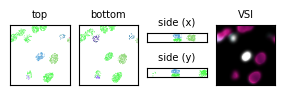

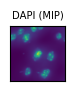

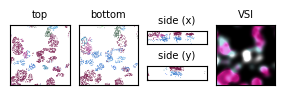

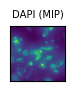

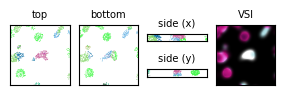

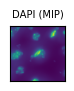

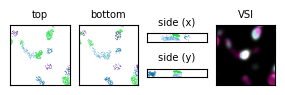

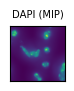

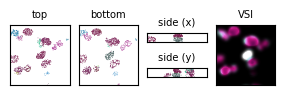

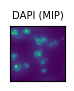

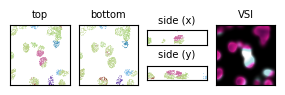

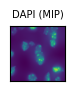

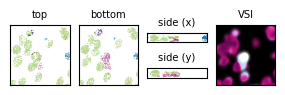

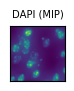

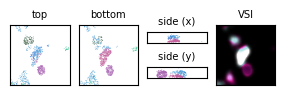

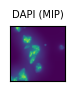

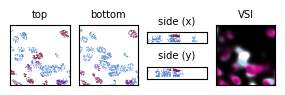

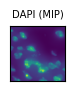

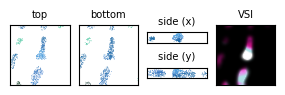

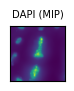

In [26]:
windowsize = 30

for i in range(10):
    x, y = doublets["x", "y"].row(i)
    fig = plot_doublet(
        brain, x, y, windowsize, signal_threshold=2, figsize=(7.2 * CM, 2.2 * CM)
    )
    fig.tight_layout()
    for j in range(4):
        fig.axes[j].collections[0].set_rasterized(True)
    fig.axes[0].add_artist(
        ScaleBar(
            1,
            units="um",
            length_fraction=0.2,
            loc="lower left",
            frameon=False,
            color="w",
        )
    )
    fig.savefig(f"nuclear_doublet_{i + 1}.png", **save_kwargs)

    fig, ax = plt.subplots(figsize=(1.8 * CM, 2.3 * CM))
    ax.set(xticks=[], yticks=[], title="DAPI (MIP)")
    ax.imshow(mip[get_range(y, windowsize), get_range(x, windowsize)])
    ax.invert_xaxis()
    fig.savefig(f"nuclear_doublet_{i + 1}_dapi.png", **save_kwargs)